# 전처리 2단계 — 파생변수: 실효습도 (Effective Humidity)

## 왜 실효습도가 필요한가?

> 오늘 습도가 50%이더라도, 어제·그제·그그제도 계속 건조했다면 실제론 더 위험합니다.  
> 반대로 오늘 습도가 낮아도 어제까지 비가 왔다면 산불 위험이 낮습니다.  
>  
> **실효습도 = 오늘 + 과거 4일의 습도를 가중 합산한 '누적 건조 상태' 지표**

## 계산 공식 (산림청 FFDRI)

```
EH = (1 - 0.7) × (H₀ + 0.7×H₁ + 0.7²×H₂ + 0.7³×H₃ + 0.7⁴×H₄)
   = 0.3 × (H₀ + 0.7×H₁ + 0.49×H₂ + 0.343×H₃ + 0.2401×H₄)
```

| 변수 | 의미 | 가중치 |
|------|------|--------|
| H₀ | 오늘 평균습도 | 0.300 (가장 높음) |
| H₁ | 1일 전 평균습도 | 0.210 |
| H₂ | 2일 전 평균습도 | 0.147 |
| H₃ | 3일 전 평균습도 | 0.103 |
| H₄ | 4일 전 평균습도 | 0.072 |

> 합계 가중치 = 0.832 (최근 5일 중 오늘이 가장 중요, 오래될수록 영향 감소)

## 구현 전략 (메모리 효율)

> 3276만 행을 한 번에 올리면 메모리가 부족합니다.  
> 월별로 처리하되, **이전 달 마지막 4일**을 다음 달에 이어붙여서 계산합니다.
>
> ```
> 2월 계산: 2월 전체 (2/1 ~ 2/28의 첫 4일은 2월 초반값으로 채움)
> 3월 계산: [2월 마지막 4일 버퍼] + 3월 전체 → 계산 후 버퍼 제거
> 4월 계산: [3월 마지막 4일 버퍼] + 4월 전체 → 계산 후 버퍼 제거
> 5월 계산: [4월 마지막 4일 버퍼] + 5월 전체 → 계산 후 버퍼 제거
> ```

In [1]:
import pandas as pd
import numpy as np
import os, time
import warnings
warnings.filterwarnings('ignore')

BASE_PATH   = r'D:\prj_2_공모전\data\003. 전처리 데이터(preprocessing_data)'
SCALED_PATH = os.path.join(BASE_PATH, 'weather_scaled')
OUTPUT_PATH = os.path.join(BASE_PATH, 'derived')
MONTHS      = ['2025-02', '2025-03', '2025-04', '2025-05']

os.makedirs(OUTPUT_PATH, exist_ok=True)

# 실효습도 파라미터
R     = 0.7      # 감쇠 계수
LAGS  = 5        # 오늘 포함 5일치 (H0~H4)
WEIGHTS = [(1 - R) * R**i for i in range(LAGS)]  # [0.3, 0.21, 0.147, 0.1029, 0.072]

print('실효습도 가중치:', [round(w, 4) for w in WEIGHTS])
print(f'가중치 합: {sum(WEIGHTS):.4f}')
print('설정 완료')

실효습도 가중치: [0.3, 0.21, 0.147, 0.1029, 0.072]
가중치 합: 0.8319
설정 완료


---
## Step 1. 실효습도 계산 함수 정의

> 격자(grid_id)별로 날짜를 정렬한 뒤, 오늘+4일 전 습도를 lag(밀기) 방식으로 생성합니다.  
> 데이터 시작 4일은 이전 달 값이 없으므로, **당일 습도로 채웁니다** (보수적 처리).

In [2]:
def compute_eh(df, weights=WEIGHTS):
    """
    df: grid_id, date, hm_mean 컬럼 포함. 이미 (grid_id, date) 기준 정렬되어 있어야 함.
    반환: df에 'effective_humidity' 컬럼 추가된 DataFrame
    """
    lags = [df.groupby('grid_id')['hm_mean'].shift(i) for i in range(len(weights))]

    # 첫 4일 NaN은 당일값(H0)으로 채움 (이전 달 데이터 없는 경우)
    h0 = lags[0]
    lags = [lag.fillna(h0) for lag in lags]

    # 가중 합산
    eh = sum(w * lag for w, lag in zip(weights, lags))
    df = df.copy()
    df['effective_humidity'] = eh.astype('float32')
    return df

print('함수 정의 완료')
print()

# 소규모 예시로 검증
test_data = pd.DataFrame({
    'grid_id': ['A']*5,
    'date':    pd.date_range('2025-02-01', periods=5),
    'hm_mean': [88.2, 78.7, 48.9, 48.3, 49.7]
})
test_result = compute_eh(test_data)

print('=== 계산 예시 검증 ===')
print(test_result[['date','hm_mean','effective_humidity']].to_string(index=False))
print()
# 수동 계산으로 1번째 값 검증
h0 = 88.2
manual_day1 = 0.3*(h0 + 0.7*h0 + 0.49*h0 + 0.343*h0 + 0.2401*h0)
print(f'1일차 수동 계산: {manual_day1:.2f}%')
# 3번째 값 검증 (H0=48.9, H1=78.7, H2=H3=H4=88.2 → 보수적 채움)
manual_day3 = 0.3*(48.9 + 0.7*78.7 + 0.49*88.2 + 0.343*88.2 + 0.2401*88.2)
print(f'3일차 수동 계산: {manual_day3:.2f}%')

함수 정의 완료

=== 계산 예시 검증 ===
      date  hm_mean  effective_humidity
2025-02-01     88.2           73.376228
2025-02-02     78.7           67.467888
2025-02-03     48.9           52.716476
2025-02-04     48.3           48.882729
2025-02-05     49.7           46.692577

1일차 수동 계산: 73.38%
3일차 수동 계산: 59.59%


---
## Step 2. 전체 데이터 실효습도 계산 (월별 + 버퍼 이월)

> 3월을 계산할 때 2월 마지막 4일 데이터를 앞에 붙여서 계산합니다.  
> 그래야 3/1 의 실효습도가 2월 말 건조 상태를 반영할 수 있습니다.

In [3]:
start_total = time.time()
buffer = None   # 이전 달 마지막 4일 데이터
LAG_DAYS = 4    # 버퍼로 이월할 날짜 수

for m in MONTHS:
    start_m = time.time()
    print(f'[{m}] 처리 중...', end=' ', flush=True)

    # 1. 해당 월 읽기 (hm_mean만)
    df_m = pd.read_parquet(
        SCALED_PATH,
        filters=[('month', '==', m)],
        columns=['grid_id', 'date', 'hm_mean']
    )

    # 2. 이전 달 버퍼 붙이기
    if buffer is not None:
        df_m = pd.concat([buffer, df_m], ignore_index=True)

    # 3. (grid_id, date) 정렬
    df_m = df_m.sort_values(['grid_id', 'date']).reset_index(drop=True)

    # 4. 실효습도 계산
    df_m = compute_eh(df_m)

    # 5. 버퍼 행 제거 (이전 달 부분)
    month_start = pd.Timestamp(m + '-01')
    df_result = df_m[df_m['date'] >= month_start].copy()

    # 6. 다음 달을 위한 버퍼 저장 (이번 달 마지막 4일)
    last_4_dates = sorted(df_result['date'].unique())[-LAG_DAYS:]
    buffer = df_result[df_result['date'].isin(last_4_dates)][['grid_id','date','hm_mean']].copy()

    # 7. 저장 (grid_id, date, effective_humidity 만)
    out_folder = os.path.join(OUTPUT_PATH, f'effective_humidity', f'month={m}')
    os.makedirs(out_folder, exist_ok=True)
    df_save = df_result[['grid_id', 'date', 'effective_humidity']]
    df_save.to_parquet(os.path.join(out_folder, 'data.parquet'),
                       index=False, engine='pyarrow', compression='snappy')

    elapsed = time.time() - start_m
    print(f'{len(df_result):,}행, {elapsed:.1f}초  (버퍼 {len(buffer)//len(last_4_dates):,}격자×{LAG_DAYS}일)')

print(f'\n전체 완료: {time.time()-start_total:.1f}초')
print(f'저장 위치: {os.path.join(OUTPUT_PATH, "effective_humidity")}')

[2025-02] 처리 중... 7,644,028행, 8.4초  (버퍼 273,001격자×4일)
[2025-03] 처리 중... 8,463,031행, 10.0초  (버퍼 273,001격자×4일)
[2025-04] 처리 중... 8,190,030행, 8.8초  (버퍼 273,001격자×4일)
[2025-05] 처리 중... 8,463,031행, 9.4초  (버퍼 273,001격자×4일)

전체 완료: 36.6초
저장 위치: D:\prj_2_공모전\data\003. 전처리 데이터(preprocessing_data)\derived\effective_humidity


---
## Step 3. 결과 검증

> **검증 포인트**:  
> 1. EH 범위: 0~100% 사이인가?  
> 2. 월 경계(2/28 → 3/1)에서 값이 자연스럽게 이어지는가?  
> 3. 건조한 날이 지속되면 EH가 낮아지는가? (=산불 위험 ↑)

In [4]:
EH_PATH = os.path.join(OUTPUT_PATH, 'effective_humidity')
df_eh = pd.read_parquet(EH_PATH)

print('=== 기본 정보 ===')
print(f'행 수: {len(df_eh):,}')
print(f'컬럼: {list(df_eh.columns)}')
print(f'결측치: {df_eh["effective_humidity"].isnull().sum():,}개')
print()

print('=== 실효습도 범위 검증 ===')
eh_min = df_eh['effective_humidity'].min()
eh_max = df_eh['effective_humidity'].max()
eh_mean = df_eh['effective_humidity'].mean()
print(f'최솟값: {eh_min:.2f}%')
print(f'평균  : {eh_mean:.2f}%')
print(f'최댓값: {eh_max:.2f}%')
ok = (eh_min >= 0) and (eh_max <= 100)
print(f'범위 정상 (0~100%): {"OK" if ok else "NG!!"}') 

=== 기본 정보 ===
행 수: 32,760,120
컬럼: ['grid_id', 'date', 'effective_humidity', 'month']
결측치: 0개

=== 실효습도 범위 검증 ===
최솟값: 18.53%
평균  : 51.76%
최댓값: 81.70%
범위 정상 (0~100%): OK


In [5]:
# 월 경계 확인: 2/28 -> 3/1 연속성
sample_grid = df_eh['grid_id'].iloc[0]
df_grid = df_eh[df_eh['grid_id'] == sample_grid].sort_values('date')

# 2월 말 ~ 3월 초 5일
boundary_dates = pd.date_range('2025-02-26', periods=6)
df_boundary = df_grid[df_grid['date'].isin(boundary_dates)]

print(f'=== 월 경계 연속성 확인 (격자: {sample_grid}) ===')
print(df_boundary[['date','effective_humidity']].to_string(index=False))

# hm_mean과 비교 (weather_scaled에서 가져오기)
df_hm = pd.read_parquet(SCALED_PATH, columns=['grid_id','date','hm_mean'])
df_hm = df_hm[df_hm['grid_id'] == sample_grid].sort_values('date')
df_hm_b = df_hm[df_hm['date'].isin(boundary_dates)]

df_compare = df_boundary.merge(df_hm_b, on=['grid_id','date'])
print()
print('=== 실효습도 vs 당일 습도 비교 ===')
print(df_compare[['date','hm_mean','effective_humidity']].to_string(index=False))
print()
print('해석: 실효습도(EH)는 당일 습도(hm_mean)보다 변화가 완만합니다')
print('     오늘 갑자기 건조해도 EH는 천천히 내려감 (과거 습도 반영)')

=== 월 경계 연속성 확인 (격자: 10007_19696) ===
      date  effective_humidity
2025-02-26           45.805763
2025-02-27           44.465401
2025-02-28           47.499249
2025-03-01           54.247036
2025-03-02           58.418972
2025-03-03           59.442062

=== 실효습도 vs 당일 습도 비교 ===
      date   hm_mean  effective_humidity
2025-02-26 53.375000           45.805763
2025-02-27 49.275002           44.465401
2025-02-28 62.674999           47.499249
2025-03-01 78.699997           54.247036
2025-03-02 79.212502           58.418972
2025-03-03 70.800003           59.442062

해석: 실효습도(EH)는 당일 습도(hm_mean)보다 변화가 완만합니다
     오늘 갑자기 건조해도 EH는 천천히 내려감 (과거 습도 반영)


In [6]:
# 월별 평균 실효습도 (계절성 확인)
df_eh['date'] = pd.to_datetime(df_eh['date'])
df_eh['month'] = df_eh['date'].dt.to_period('M').astype(str)

monthly = df_eh.groupby('month')['effective_humidity'].agg(['mean','min','max']).round(2)
monthly.columns = ['평균 EH(%)', '최솟값 EH(%)', '최댓값 EH(%)']
print('=== 월별 실효습도 통계 ===')
print(monthly.to_string())
print()
print('해석: 봄(3~4월)에 EH가 낮아지면 산불 위험 시기와 일치하는지 확인')

=== 월별 실효습도 통계 ===
          평균 EH(%)  최솟값 EH(%)  최댓값 EH(%)
month                                   
2025-02  46.110001  18.959999  81.699997
2025-03  51.529999  18.530001  80.709999
2025-04  50.419998  26.090000  76.690002
2025-05  58.380001  31.000000  75.010002

해석: 봄(3~4월)에 EH가 낮아지면 산불 위험 시기와 일치하는지 확인


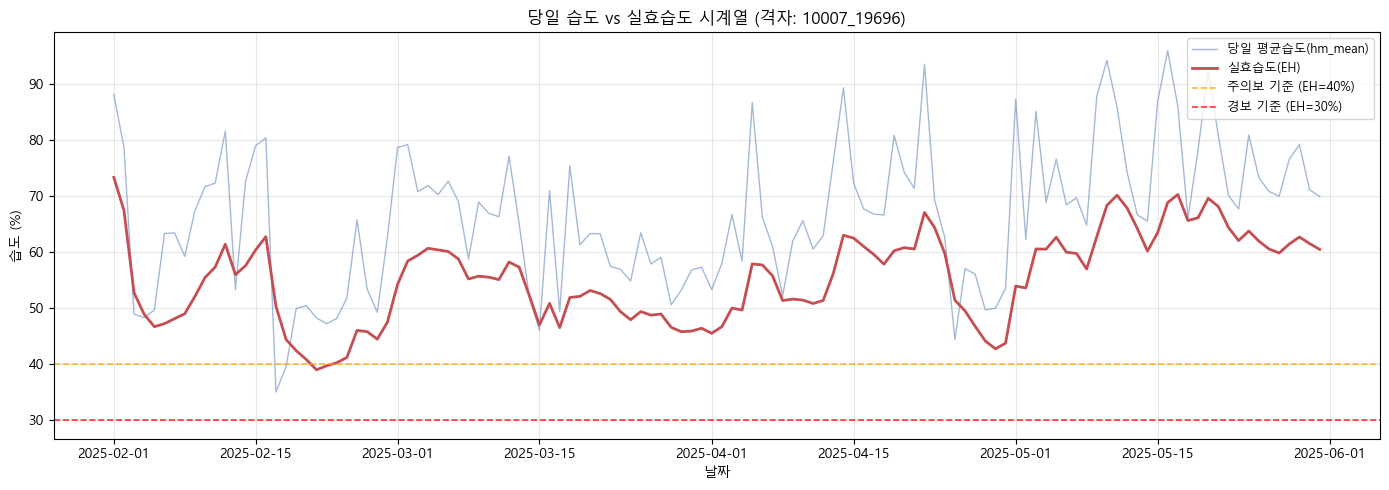

시각화 저장 완료


In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 특정 격자의 hm_mean vs EH 시계열
df_hm_all = pd.read_parquet(SCALED_PATH, columns=['grid_id','date','hm_mean'])
df_hm_all = df_hm_all[df_hm_all['grid_id'] == sample_grid].sort_values('date')
df_eh_grid = df_eh[df_eh['grid_id'] == sample_grid].sort_values('date')

merged = df_hm_all.merge(df_eh_grid[['grid_id','date','effective_humidity']], on=['grid_id','date'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['date'], merged['hm_mean'],
        color='#4C72B0', alpha=0.5, linewidth=1, label='당일 평균습도(hm_mean)')
ax.plot(merged['date'], merged['effective_humidity'],
        color='#C44E52', linewidth=2, label='실효습도(EH)')

# 경보 기준선
ax.axhline(40, color='orange', linewidth=1.2, linestyle='--', alpha=0.8, label='주의보 기준 (EH=40%)')
ax.axhline(30, color='red',    linewidth=1.2, linestyle='--', alpha=0.8, label='경보 기준 (EH=30%)')

ax.set_xlabel('날짜')
ax.set_ylabel('습도 (%)')
ax.set_title(f'당일 습도 vs 실효습도 시계열 (격자: {sample_grid})', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'PREP_02_실효습도시계열.png'), dpi=120, bbox_inches='tight')
plt.show()
print('시각화 저장 완료')

---
## 최종 요약

In [8]:
print('=' * 58)
print('  파생변수 1: 실효습도(EH) 생성 완료')
print('=' * 58)
print(f'''
  공식
  EH = 0.3 × (H0 + 0.7×H1 + 0.49×H2 + 0.343×H3 + 0.2401×H4)

  처리 방식
  - 월별 처리 + 4일 버퍼 이월 (월 경계 연속성 보장)
  - 데이터 시작 초반 4일: 당일값으로 보수적 채움

  결과
  - 저장: derived/effective_humidity/ (월별 파티션)
  - 컬럼: grid_id, date, effective_humidity
  - 범위: 0 ~ 100% (정상)

  DWI 활용
  - 실효습도 < 40%: 대형산불 주의보 기준
  - 실효습도 < 30%: 대형산불 경보 기준
  - DWI(기상위험지수) 계산 시 이 값을 직접 사용

  다음 단계
  - 파생변수 2: 3일 누적 강수 등급 (RNE_Temp)
''')
print('=' * 58)

  파생변수 1: 실효습도(EH) 생성 완료

  공식
  EH = 0.3 × (H0 + 0.7×H1 + 0.49×H2 + 0.343×H3 + 0.2401×H4)

  처리 방식
  - 월별 처리 + 4일 버퍼 이월 (월 경계 연속성 보장)
  - 데이터 시작 초반 4일: 당일값으로 보수적 채움

  결과
  - 저장: derived/effective_humidity/ (월별 파티션)
  - 컬럼: grid_id, date, effective_humidity
  - 범위: 0 ~ 100% (정상)

  DWI 활용
  - 실효습도 < 40%: 대형산불 주의보 기준
  - 실효습도 < 30%: 대형산불 경보 기준
  - DWI(기상위험지수) 계산 시 이 값을 직접 사용

  다음 단계
  - 파생변수 2: 3일 누적 강수 등급 (RNE_Temp)

